# Decision Tree Weather Type Classification

This notebook builds one model only: a Decision Tree classifier for the Kaggle Weather Type Classification dataset. It includes preprocessing in a scikit-learn pipeline for numeric and categorical columns.

## 1. Imports

This cell imports the libraries used for data loading, preprocessing, model building, evaluation, and plotting.  
These tools are enough to take the dataset from raw CSV form all the way to final predictions.

In [1]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# We import every external library we will need before doing any work.
# Grouping imports at the top is a Python best-practice (PEP 8) and makes
# dependencies visible at a glance.
#
# Key choices explained:
#   pandas / numpy  – industry-standard tabular-data and array libraries.
#   matplotlib      – lets us plot feature importances later.
#   Pipeline        – chains preprocessing + model into ONE object so the
#                     same transformations are always applied in the right
#                     order, preventing data-leakage bugs.
#   ColumnTransformer – applies different preprocessing to numeric vs
#                       categorical columns simultaneously.
#   DecisionTreeClassifier – our chosen model (see section 4 for rationale).
#   SimpleImputer   – fills missing values; without it the model crashes
#                     on NaN entries.
#   LabelEncoder    – converts string class names (Sunny, Rainy …) to
#                     integers that sklearn requires.
#   OneHotEncoder   – converts categorical text columns into binary
#                     numeric columns the tree can split on.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# We import every external library we will need before doing any work.
# Grouping imports at the top is a Python best-practice (PEP 8) and makes
# dependencies visible at a glance.
#
# Key choices explained:
#   pandas / numpy  – industry-standard tabular-data and array libraries.
#   matplotlib      – lets us plot feature importances later.
#   Pipeline        – chains preprocessing + model into ONE object so the
#                     same transformations are always applied in the right
#                     order, preventing data-leakage bugs.
#   ColumnTransformer – applies different preprocessing to numeric vs
#                       categorical columns simultaneously.
#   DecisionTreeClassifier – our chosen model (see section 4 for rationale).
#   SimpleImputer   – fills missing values; without it the model crashes
#                     on NaN entries.
#   LabelEncoder    – converts string class names (Sunny, Rainy …) to
#                     integers that sklearn requires.
#   OneHotEncoder   – converts categorical text columns into binary
#                     numeric columns the tree can split on.
# ──────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

## 2. Load Dataset

This cell reads the weather dataset from a CSV file.  
If the file name is correct and the CSV is in the same folder as the notebook, the dataset will load into a pandas DataFrame.

In [2]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# We load the CSV data file into a pandas DataFrame so we can inspect,
# split, and feed it to the model.
#
# df.head() lets us quickly verify the file loaded correctly and confirms
# the column names we will reference throughout the notebook.
#
# If we skip this step, nothing downstream works – there is no data.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# We load the CSV data file into a pandas DataFrame so we can inspect,
# split, and feed it to the model.
#
# df.head() lets us quickly verify the file loaded correctly and confirms
# the column names we will reference throughout the notebook.
#
# If we skip this step, nothing downstream works – there is no data.
# ──────────────────────────────────────────────────────────────────────────
DATA_PATH = "weather_classification_data.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [3]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# Before modelling we need to understand the data:
#   df.shape            – confirms row and column counts.
#   df.info()           – reveals dtypes and non-null counts, exposing
#                         any hidden missing values.
#   df.describe(include='all') – gives statistics (mean, std, min/max for
#                         numeric columns; count/unique/top for categories).
#
# Skipping exploratory analysis risks:
#   - Columns with unexpected types breaking the preprocessor.
#   - Missing class imbalances that affect model evaluation.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# Before modelling we need to understand the data:
#   df.shape            – confirms row and column counts.
#   df.info()           – reveals dtypes and non-null counts, exposing
#                         any hidden missing values.
#   df.describe(include='all') – gives statistics (mean, std, min/max for
#                         numeric columns; count/unique/top for categories).
#
# Skipping exploratory analysis risks:
#   - Columns with unexpected types breaking the preprocessor.
#   - Missing class imbalances that affect model evaluation.
# ──────────────────────────────────────────────────────────────────────────
print("Dataset shape:", df.shape)
display(df.info())
df.describe(include="all")

Dataset shape: (13200, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


None

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
count,13200.000000,13200.000000,13200.000000,13200.000000,13200,13200.000000,13200.000000,13200,13200.000000,13200,13200
unique,NaN,NaN,NaN,NaN,4,NaN,NaN,4,NaN,3,4
top,NaN,NaN,NaN,NaN,overcast,NaN,NaN,Winter,NaN,inland,Rainy
freq,NaN,NaN,NaN,NaN,6090,NaN,NaN,5610,NaN,4816,3300
mean,19.127576,68.710833,9.832197,53.644394,NaN,1005.827896,4.005758,NaN,5.462917,NaN,NaN
std,17.386327,20.194248,6.908704,31.946541,NaN,37.199589,3.856600,NaN,3.371499,NaN,NaN
min,-25.000000,20.000000,0.000000,0.000000,NaN,800.120000,0.000000,NaN,0.000000,NaN,NaN
25%,4.000000,57.000000,5.000000,19.000000,NaN,994.800000,1.000000,NaN,3.000000,NaN,NaN
50%,21.000000,70.000000,9.000000,58.000000,NaN,1007.650000,3.000000,NaN,5.000000,NaN,NaN
75%,31.000000,84.000000,13.500000,82.000000,NaN,1016.772500,7.000000,NaN,7.500000,NaN,NaN


## 3. Split Features and Target

This cell separates the input columns (**features**) from the output column (**target**).  
The target for this project is `Weather Type`, which is the label the model will learn to predict.

In [4]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# Machine-learning models require a clear separation between:
#   X  – the features (inputs the model uses to make predictions).
#   y  – the target (the label we want the model to predict).
#
# We apply LabelEncoder to y because sklearn estimators require numeric
# class labels, not strings like 'Sunny'. We keep the encoder object so
# we can later invert it (decode predictions back to readable names).
#
# The ValueError guard ensures we fail gracefully with a helpful message
# if the expected column is missing.
#
# Without this step, no X or y means no model can be built.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# Machine-learning models require a clear separation between:
#   X  – the features (inputs the model uses to make predictions).
#   y  – the target (the label we want the model to predict).
#
# We apply LabelEncoder to y because sklearn estimators require numeric
# class labels, not strings like 'Sunny'. We keep the encoder object so
# we can later invert it (decode predictions back to readable names).
#
# The ValueError guard ensures we fail gracefully with a helpful message
# if the expected column is missing.
#
# Without this step, no X or y means no model can be built.
# ──────────────────────────────────────────────────────────────────────────
TARGET_COLUMN = "Weather Type"

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Expected target column '{TARGET_COLUMN}', but found: {list(df.columns)}")

X = df.drop(columns=[TARGET_COLUMN])

# Encode the target weather condition labels as numbers.
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df[TARGET_COLUMN])
target_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))

print("Feature columns:", list(X.columns))
print("Target encoding:", target_mapping)

Feature columns: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location']
Target encoding: {'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}


In [5]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# We split data into THREE non-overlapping sets:
#
#   Training set   (~70%) – used to fit the model parameters.
#   Validation set (~15%) – used to tune hyperparameters WITHOUT touching
#                           the test set.
#   Test set       (~15%) – held out entirely; used ONCE at the end to
#                           report an unbiased final accuracy.
#
# Why stratify=y?
#   Ensures each split has the same class proportions as the full dataset,
#   preventing a split from having, say, zero Snowy examples.
#
# Why random_state=42?
#   Fixes the random seed so results are fully reproducible across runs.
#
# Without a proper test-set holdout we have no honest estimate of
# how the model performs on completely unseen, real-world data.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# We split data into THREE non-overlapping sets:
#
#   Training set   (~70%) – used to fit the model parameters.
#   Validation set (~15%) – used to tune hyperparameters WITHOUT touching
#                           the test set.
#   Test set       (~15%) – held out entirely; used ONCE at the end to
#                           report an unbiased final accuracy.
#
# Why stratify=y?
#   Ensures each split has the same class proportions as the full dataset,
#   preventing a split from having, say, zero Snowy examples.
#
# Why random_state=42?
#   Fixes the random seed so results are fully reproducible across runs.
#
# Without a proper test-set holdout we have no honest estimate of
# how the model performs on completely unseen, real-world data.
# ──────────────────────────────────────────────────────────────────────────
# First split: hold out 15% for the final test set.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Second split: take validation data from the remaining 85%.
# This gives approximately 70% training, 15% validation, and 15% testing.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_val
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_val.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 9239
Validation rows: 1981
Testing rows: 1980


## 4. Preprocessing and Decision Tree Pipeline

Numeric columns use median imputation for missing values. Categorical columns use most-frequent imputation and one-hot encoding. Decision Trees do not require feature scaling, so scaling is intentionally not included.

In [6]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# We identify which columns are numeric and which are categorical so
# the ColumnTransformer can apply different preprocessing to each group.
#
# Why separate numeric and categorical?
#   - Numeric features need imputation for missing values but can be
#     passed directly as numbers to the tree.
#   - Categorical features (strings like 'overcast') must be converted
#     to numbers before the tree can evaluate them in splits.
#
# condition_features is a convenience list used in the preview below.
#
# Skipping this step would cause either a runtime error or silently
# incorrect preprocessing.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# We identify which columns are numeric and which are categorical so
# the ColumnTransformer can apply different preprocessing to each group.
#
# Why separate numeric and categorical?
#   - Numeric features need imputation for missing values but can be
#     passed directly as numbers to the tree.
#   - Categorical features (strings like 'overcast') must be converted
#     to numbers before the tree can evaluate them in splits.
#
# condition_features is a convenience list used in the preview below.
#
# Skipping this step would cause either a runtime error or silently
# incorrect preprocessing.
# ──────────────────────────────────────────────────────────────────────────
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
condition_features = [col for col in ["Cloud Cover", "Season", "Location"] if col in X.columns]

print("Numeric features:", numeric_features)
print("Categorical features encoded with OneHotEncoder:", categorical_features)
print("Condition features:", condition_features)

Numeric features: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
Categorical features encoded with OneHotEncoder: ['Cloud Cover', 'Season', 'Location']
Condition features: ['Cloud Cover', 'Season', 'Location']


The next cell shows what condition encoding looks like. The model still uses the pipeline below so encoding is learned only from the training data.

In [7]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# This is a VISUAL PREVIEW ONLY – it is NOT part of actual training.
# pd.get_dummies is called on the full X just to show what one-hot
# encoded columns look like (0s and 1s instead of text).
#
# Why a preview and not the real encoding?
#   The real encoding inside the Pipeline is fitted ONLY on X_train.
#   Using the full X here would leak val/test category distributions
#   into the encoder (data leakage). This cell helps a reader understand
#   the encoding transformation without affecting any model data.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# This is a VISUAL PREVIEW ONLY – it is NOT part of actual training.
# pd.get_dummies is called on the full X just to show what one-hot
# encoded columns look like (0s and 1s instead of text).
#
# Why a preview and not the real encoding?
#   The real encoding inside the Pipeline is fitted ONLY on X_train.
#   Using the full X here would leak val/test category distributions
#   into the encoder (data leakage). This cell helps a reader understand
#   the encoding transformation without affecting any model data.
# ──────────────────────────────────────────────────────────────────────────
if condition_features:
    encoded_condition_preview = pd.get_dummies(
        X[condition_features],
        columns=condition_features,
        dtype=int
    )
    display(encoded_condition_preview.head())
else:
    print("No condition columns found for encoding.")

,Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
0,0,0,0,1,0,0,0,1,0,1,0
1,0,0,0,1,0,1,0,0,0,1,0
2,1,0,0,0,0,1,0,0,0,0,1
3,1,0,0,0,0,1,0,0,1,0,0
4,0,0,1,0,0,0,0,1,0,0,1


In [8]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# This cell assembles the full scikit-learn Pipeline:
#
#   numeric_preprocessor:
#     SimpleImputer(strategy='median') – replaces NaN values with the
#     column median. Median is more robust to outliers than mean.
#     No StandardScaler is used because Decision Trees split on
#     thresholds, not distances, so feature scale does not affect results.
#
#   categorical_preprocessor:
#     SimpleImputer(strategy='most_frequent') – fills missing categories.
#     OneHotEncoder(handle_unknown='ignore') – converts text categories
#     to binary columns. handle_unknown ensures unseen categories at
#     prediction time are silently ignored instead of raising an error.
#
#   DecisionTreeClassifier – chosen because:
#     - It is interpretable (the tree structure can be visualised).
#     - It handles both numeric and (encoded) categorical features.
#     - class_weight='balanced' compensates for any class imbalance.
#     - random_state=42 ensures reproducible tree-building decisions.
#
# Wrapping everything in a Pipeline ensures fit() and predict() always
# apply the SAME transformations in the SAME order, eliminating a common
# source of bugs and data leakage when predicting on new data.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# This cell assembles the full scikit-learn Pipeline:
#
#   numeric_preprocessor:
#     SimpleImputer(strategy='median') – replaces NaN values with the
#     column median. Median is more robust to outliers than mean.
#     No StandardScaler is used because Decision Trees split on
#     thresholds, not distances, so feature scale does not affect results.
#
#   categorical_preprocessor:
#     SimpleImputer(strategy='most_frequent') – fills missing categories.
#     OneHotEncoder(handle_unknown='ignore') – converts text categories
#     to binary columns. handle_unknown ensures unseen categories at
#     prediction time are silently ignored instead of raising an error.
#
#   DecisionTreeClassifier – chosen because:
#     - It is interpretable (the tree structure can be visualised).
#     - It handles both numeric and (encoded) categorical features.
#     - class_weight='balanced' compensates for any class imbalance.
#     - random_state=42 ensures reproducible tree-building decisions.
#
# Wrapping everything in a Pipeline ensures fit() and predict() always
# apply the SAME transformations in the SAME order, eliminating a common
# source of bugs and data leakage when predicting on new data.
# ──────────────────────────────────────────────────────────────────────────
numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_preprocessor, numeric_features),
    ("categorical", categorical_preprocessor, categorical_features)
])

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        class_weight="balanced"
    ))
])

dt_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Temperature', 'Humidity',
                                                   'Wind Speed',
                                                   'Precipitation (%)',
                                                   'Atmospheric Pressure',
                                                   'UV Index',
                                                   'Visibility (km)']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Cloud Cover', 'Season',
                                                   'Location'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

## 5. Train Model

In [9]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# dt_pipeline.fit(X_train, y_train) triggers two things at once:
#   1. The preprocessor fits imputers and encoders on X_train (learning
#      medians, category lists, etc.) and then transforms X_train.
#   2. The DecisionTreeClassifier learns the best splits on the transformed
#      features to predict y_train.
#
# ONLY X_train is used here. The validation and test sets are never seen
# during fitting, which is essential for obtaining unbiased metrics.
#
# Training on all data (X instead of X_train) would cause the model to
# memorise the test answers, producing unrealistically high accuracy
# (a mistake known as data leakage).
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# dt_pipeline.fit(X_train, y_train) triggers two things at once:
#   1. The preprocessor fits imputers and encoders on X_train (learning
#      medians, category lists, etc.) and then transforms X_train.
#   2. The DecisionTreeClassifier learns the best splits on the transformed
#      features to predict y_train.
#
# ONLY X_train is used here. The validation and test sets are never seen
# during fitting, which is essential for obtaining unbiased metrics.
#
# Training on all data (X instead of X_train) would cause the model to
# memorise the test answers, producing unrealistically high accuracy
# (a mistake known as data leakage).
# ──────────────────────────────────────────────────────────────────────────
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Temperature', 'Humidity',
                                                   'Wind Speed',
                                                   'Precipitation (%)',
                                                   'Atmospheric Pressure',
                                                   'UV Index',
                                                   'Visibility (km)']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Cloud Cover', 'Season',
                                                   'Location'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

## 6. Validation Evaluation

In [10]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# We evaluate the trained model on the VALIDATION set (X_val / y_val).
#
# Why validate before testing?
#   The validation set provides early-warning accuracy. If unsatisfactory,
#   we can adjust hyperparameters (e.g. max_depth) and re-train WITHOUT
#   peeking at the test set. Using the test set for this would bias the
#   final performance estimate.
#
#   accuracy_score        – fraction of rows predicted correctly.
#   classification_report – per-class precision, recall, and F1-score,
#                           which matter when classes are imbalanced.
#
# Without a validation phase we would have no development feedback and
# would be forced to use the test set, defeating its purpose.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# We evaluate the trained model on the VALIDATION set (X_val / y_val).
#
# Why validate before testing?
#   The validation set provides early-warning accuracy. If unsatisfactory,
#   we can adjust hyperparameters (e.g. max_depth) and re-train WITHOUT
#   peeking at the test set. Using the test set for this would bias the
#   final performance estimate.
#
#   accuracy_score        – fraction of rows predicted correctly.
#   classification_report – per-class precision, recall, and F1-score,
#                           which matter when classes are imbalanced.
#
# Without a validation phase we would have no development feedback and
# would be forced to use the test set, defeating its purpose.
# ──────────────────────────────────────────────────────────────────────────
y_val_pred = dt_pipeline.predict(X_val)

validation_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {validation_accuracy:.4f}")
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=target_encoder.classes_))

Validation Accuracy: 0.9056

Validation Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.88      0.88      0.88       495
       Rainy       0.87      0.90      0.89       495
       Snowy       0.94      0.94      0.94       496
       Sunny       0.94      0.90      0.92       495

    accuracy                           0.91      1981
   macro avg       0.91      0.91      0.91      1981
weighted avg       0.91      0.91      0.91      1981



In [11]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# The confusion matrix shows WHICH classes are being confused, not just
# how many predictions are wrong overall.
#
# Each row is the actual class; each column is the predicted class.
# Off-diagonal cells reveal systematic errors, e.g. the model often
# predicts 'Cloudy' when the truth is 'Rainy'.
#
# This insight can guide feature engineering or class-weight adjustments.
# Without it we cannot distinguish uniform errors from systematic ones.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# The confusion matrix shows WHICH classes are being confused, not just
# how many predictions are wrong overall.
#
# Each row is the actual class; each column is the predicted class.
# Off-diagonal cells reveal systematic errors, e.g. the model often
# predicts 'Cloudy' when the truth is 'Rainy'.
#
# This insight can guide feature engineering or class-weight adjustments.
# Without it we cannot distinguish uniform errors from systematic ones.
# ──────────────────────────────────────────────────────────────────────────
cm = confusion_matrix(y_val, y_val_pred, labels=range(len(target_encoder.classes_)))
cm_df = pd.DataFrame(cm, index=target_encoder.classes_, columns=target_encoder.classes_)
cm_df

,Cloudy,Rainy,Snowy,Sunny
Cloudy,436,35,9,15
Rainy,31,445,11,8
Snowy,12,10,466,8
Sunny,17,20,11,447


## 7. Cross-Validation

In [12]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# Cross-validation (cv=5) splits the training data into 5 folds.
# The model is trained on 4 folds and evaluated on the 5th, cycling
# through all combinations.
#
# Why use cross-validation?
#   A single train/validation split can be lucky or unlucky depending on
#   which samples end up in each partition. CV averages over 5 different
#   splits, giving a more reliable generalisation estimate and quantifying
#   its variance via the standard deviation.
#
# n_jobs=1 – sequential execution keeps results deterministic and
# avoids resource issues in shared/cloud environments.
#
# Without CV we could unknowingly pick a configuration that works well
# on one particular split but poorly on others.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# Cross-validation (cv=5) splits the training data into 5 folds.
# The model is trained on 4 folds and evaluated on the 5th, cycling
# through all combinations.
#
# Why use cross-validation?
#   A single train/validation split can be lucky or unlucky depending on
#   which samples end up in each partition. CV averages over 5 different
#   splits, giving a more reliable generalisation estimate and quantifying
#   its variance via the standard deviation.
#
# n_jobs=1 – sequential execution keeps results deterministic and
# avoids resource issues in shared/cloud environments.
#
# Without CV we could unknowingly pick a configuration that works well
# on one particular split but poorly on others.
# ──────────────────────────────────────────────────────────────────────────
cv_scores = cross_val_score(dt_pipeline, X_train, y_train, cv=5, scoring="accuracy", n_jobs=1)

print("CV scores:", cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV standard deviation: {cv_scores.std():.4f}")

CV scores: [0.90800866 0.90638528 0.90800866 0.91179654 0.91608013]
Mean CV accuracy: 0.9101
CV standard deviation: 0.0035


## 8. Feature Importance

In [13]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# After fitting, DecisionTreeClassifier stores feature_importances_,
# which measure how much each feature reduces impurity (Gini) across
# all splits in the tree.
#
# Why extract feature importances?
#   - Reveals WHAT the model has learned (which weather variables matter).
#   - Can guide feature selection in future experiments.
#   - Acts as a sanity check: an irrelevant feature at the top may signal
#     data leakage or a labelling error.
#
# get_feature_names_out() retrieves human-readable names from the
# ColumnTransformer, including one-hot-encoded column names.
#
# Without this step we treat the model as a black box and lose the
# interpretability that Decision Trees are specifically valued for.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# After fitting, DecisionTreeClassifier stores feature_importances_,
# which measure how much each feature reduces impurity (Gini) across
# all splits in the tree.
#
# Why extract feature importances?
#   - Reveals WHAT the model has learned (which weather variables matter).
#   - Can guide feature selection in future experiments.
#   - Acts as a sanity check: an irrelevant feature at the top may signal
#     data leakage or a labelling error.
#
# get_feature_names_out() retrieves human-readable names from the
# ColumnTransformer, including one-hot-encoded column names.
#
# Without this step we treat the model as a black box and lose the
# interpretability that Decision Trees are specifically valued for.
# ──────────────────────────────────────────────────────────────────────────
feature_names = dt_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = dt_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
0,numeric__Temperature,0.281557
5,numeric__UV Index,0.242806
6,numeric__Visibility (km),0.237246
3,numeric__Precipitation (%),0.076895
4,numeric__Atmospheric Pressure,0.038164
1,numeric__Humidity,0.026909
2,numeric__Wind Speed,0.026782
7,categorical__Cloud Cover_clear,0.026386
14,categorical__Season_Winter,0.024768
8,categorical__Cloud Cover_cloudy,0.002965


<Axes: title={'center': 'Top 20 Decision Tree Feature Importances'}, ylabel='feature'>

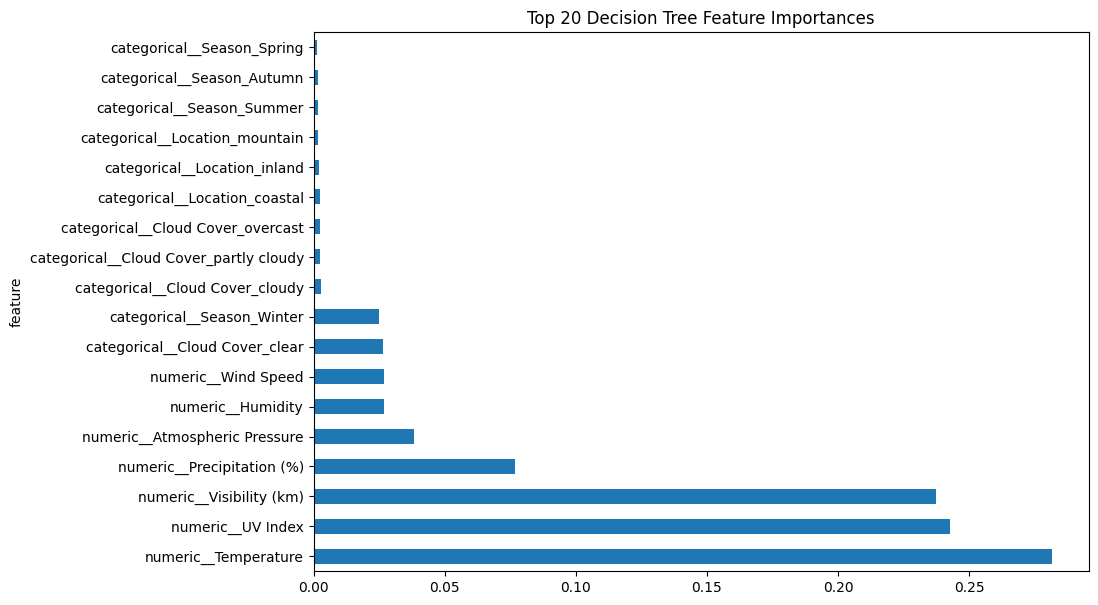

In [14]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# A horizontal bar chart makes feature importances easy to compare at a
# glance, showing the top-20 most influential features ranked from most
# to least important.
#
# Visual representation matters because:
#   - A raw table of 18+ numbers is difficult to parse quickly.
#   - A chart immediately highlights the dominant features.
#
# Without this plot, stakeholders would need to read through a data table
# to draw the same conclusions, increasing the risk of misinterpretation.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# A horizontal bar chart makes feature importances easy to compare at a
# glance, showing the top-20 most influential features ranked from most
# to least important.
#
# Visual representation matters because:
#   - A raw table of 18+ numbers is difficult to parse quickly.
#   - A chart immediately highlights the dominant features.
#
# Without this plot, stakeholders would need to read through a data table
# to draw the same conclusions, increasing the risk of misinterpretation.
# ──────────────────────────────────────────────────────────────────────────
importance_df.head(20).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(10, 7),
    legend=False,
    title="Top 20 Decision Tree Feature Importances"
)

## 9. Final Held-Out Test Set Evaluation

Use the test set once at the end after training and validation are complete.

In [15]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# This is the FINAL, HONEST evaluation of the model on data it has NEVER
# seen during training or validation (X_test / y_test).
#
# The test set is used ONLY ONCE and ONLY HERE.  Using it earlier would
# bias the performance estimate upward because we would have implicitly
# optimised for the test data.
#
# We report both accuracy and the full classification report (per-class
# precision, recall, F1) so readers can assess performance across all
# four weather types, not just the aggregate average.
#
# Without a proper held-out test set we cannot make any trustworthy
# claim about how the model will perform in real-world deployment.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# This is the FINAL, HONEST evaluation of the model on data it has NEVER
# seen during training or validation (X_test / y_test).
#
# The test set is used ONLY ONCE and ONLY HERE.  Using it earlier would
# bias the performance estimate upward because we would have implicitly
# optimised for the test data.
#
# We report both accuracy and the full classification report (per-class
# precision, recall, F1) so readers can assess performance across all
# four weather types, not just the aggregate average.
#
# Without a proper held-out test set we cannot make any trustworthy
# claim about how the model will perform in real-world deployment.
# ──────────────────────────────────────────────────────────────────────────
y_test_pred = dt_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_encoder.classes_))

Final Test Accuracy: 0.9051

Final Test Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.87      0.90      0.88       495
       Rainy       0.88      0.91      0.89       495
       Snowy       0.96      0.91      0.93       495
       Sunny       0.92      0.91      0.92       495

    accuracy                           0.91      1980
   macro avg       0.91      0.91      0.91      1980
weighted avg       0.91      0.91      0.91      1980



In [16]:
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# Same motivation as the validation confusion matrix, but now applied to
# the test set.  This confirms whether the error pattern seen during
# validation persists on completely unseen data.
#
# Comparing validation vs. test confusion matrices helps detect:
#   - Overfitting to the validation split (if patterns change markedly).
#   - Consistent systematic errors that could guide future improvements.
# ──────────────────────────────────────────────────────────────────────────
# ── WHY THIS CELL EXISTS ──────────────────────────────────────────────────
# Same motivation as the validation confusion matrix, but now applied to
# the test set.  This confirms whether the error pattern seen during
# validation persists on completely unseen data.
#
# Comparing validation vs. test confusion matrices helps detect:
#   - Overfitting to the validation split (if patterns change markedly).
#   - Consistent systematic errors that could guide future improvements.
# ──────────────────────────────────────────────────────────────────────────
test_cm = confusion_matrix(y_test, y_test_pred, labels=range(len(target_encoder.classes_)))
test_cm_df = pd.DataFrame(test_cm, index=target_encoder.classes_, columns=target_encoder.classes_)
test_cm_df

,Cloudy,Rainy,Snowy,Sunny
Cloudy,445,33,6,11
Rainy,32,448,5,10
Snowy,19,11,448,17
Sunny,18,17,9,451
